In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_csv_df
from src.plotting import set_plotting_style

In [2]:
# Already prepared accent palette applying using function from mine src module (plotting)
set_plotting_style()

In [3]:
DF_PATH = "../data/raw/raw-data.csv"

# Safely loading dataframe using function from mine src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\data\raw\raw-data.csv
Dataframe has: 195 rows / 10 columns
Dataframe size: 0.024MB


In [4]:
df.info()
"""Dataframe overview:
-------------------------
- Shape: 195 rows and 10 columns
- Data types: 9 numerical features (float64) and 1 categorial features (str)
- Features: some features name is non-standard, they include spaces, special characters, and numbers
(e.g., % water, % of world population, HDI, Land in km2)
"""

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country name           195 non-null    str    
 1   Total in km2           195 non-null    float64
 2   Land in km2            194 non-null    float64
 3   Inland water in km2    194 non-null    float64
 4   % water                194 non-null    float64
 5   Population             194 non-null    float64
 6   % of world population  194 non-null    float64
 7   Population density     194 non-null    float64
 8   HDI                    190 non-null    float64
 9   Fertility rate         191 non-null    float64
dtypes: float64(9), str(1)
memory usage: 15.4 KB


'Dataframe overview:\n-------------------------\n- Shape: 195 rows and 10 columns\n- Data types: 9 numerical features (float64) and 1 categorial features (str)\n- Features: some features name is non-standard, they include spaces, special characters, and numbers\n(e.g., % water, % of world population, HDI, Land in km2)\n'

In [5]:
display(df.head(5))
display(df.tail(5))
"""Dataframe observation:
----------------------------
- 'Country name' acts as a unique row identifier and should be moved to index
- Features like 'Population' and 'Total in km2' contain massive numbers.
While '% water', '% of world population' and 'HDI' are decimal. Scaler
is strictly necessary.
"""

,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59


,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate
190,San Marino,61.00,61.00,0.0,0.0,34167.0,0.0004,560.11,0.915,1.17
191,Tuvalu,26.00,26.00,0.0,0.0,10643.0,0.0001,409.35,0.689,3.10
192,Nauru,21.00,20.00,0.0,0.0,11680.0,0.0001,556.19,0.703,3.21
193,Monaco,2.00,2.00,0.0,0.0,38857.0,0.0005,19428.50,NaN,2.09
194,Vatican City,0.44,0.44,0.0,0.0,882.0,0.0000,2004.55,NaN,1.00


"Dataframe observation:\n----------------------------\n- 'Country name' acts as a unique row identifier and should be moved to index\n- Features like 'Population' and 'Total in km2' contain massive numbers.\nWhile '% water', '% of world population' and 'HDI' are decimal. Scaler\nis strictly necessary.\n"

In [6]:
country_unique_values = df["Country name"].unique()
print(f"Country name unique: {len(country_unique_values)} values")
"""Country name observation:
--------------------------------
- As i expected, 'Country name' is just identifier and
has 195 unique values (195 rows in dataframe summary).
"""

Country name unique: 195 values


"Country name observation:\n--------------------------------\n- As i expected, 'Country name' is just identifier and\nhas 195 unique values (195 rows in dataframe summary).\n"

In [7]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df.describe().T)

print(f"HDI median: {df['HDI'].median():.3f}")
print(f"% water median: {df['% water'].median():.3f}")
print(f"% water sum: {df['% water'].sum():.2f}%") # % water not in world but in specified country
"""Dataframe observation:
-------------------------
- Already see NaN in count (e.g., 'Fertility rate' missing 4 values, summary row count is 195 but
in feature is 191 instead, all features have at least 1 missing value exclude 'Total in km2').
- 'Total in km2' has correct outliers (Country have huge difference in territory).
The same applies to 'Population' and 'Population density'.
- '% water' highly skewed towards 0 (median is only 1.4%).
- 'HDI' and 'Fertility rate' have reasonable ranges but contain minor missing values.
"""

,count,mean,std,min,25%,50%,75%,max
Total in km2,195.00,685093.57,1909727.92,0.44,23082.50,118484.00,509245.00,17098246.00
Land in km2,194.00,664691.99,1840054.05,0.44,22902.50,112325.00,492412.50,16376870.00
Inland water in km2,194.00,20595.49,91053.49,0.00,11.50,1592.50,9022.50,891163.00
% water,194.00,2.57,4.10,0.00,0.10,1.40,3.18,27.80
Population,194.00,41395284.66,149140967.70,882.00,1846638.00,9244136.50,31879025.00,1429404000.00
% of world population,194.00,0.50,1.81,0.00,0.02,0.10,0.40,17.30
Population density,194.00,317.36,1524.83,2.30,33.50,86.57,202.20,19428.50
HDI,190.00,0.74,0.15,0.39,0.62,0.76,0.86,0.97
Fertility rate,191.00,2.35,1.11,0.76,1.49,1.93,3.08,5.84


HDI median: 0.762
% water median: 1.400
% water sum: 498.15%


"Dataframe observation:\n-------------------------\n- Already see NaN in count (e.g., 'Fertility rate' missing 4 values, summary row count is 195 but\nin feature is 191 instead, all features have at least 1 missing value exclude 'Total in km2').\n- 'Total in km2' has correct outliers (Country have huge difference in territory).\nThe same applies to 'Population' and 'Population density'.\n- '% water' highly skewed towards 0 (median is only 1.4%).\n- 'HDI' and 'Fertility rate' have reasonable ranges but contain minor missing values.\n"

In [8]:
df_dup = df.duplicated().sum() # 0 duplicates
print(f"Duplicated rows: {df_dup}")

Duplicated rows: 0


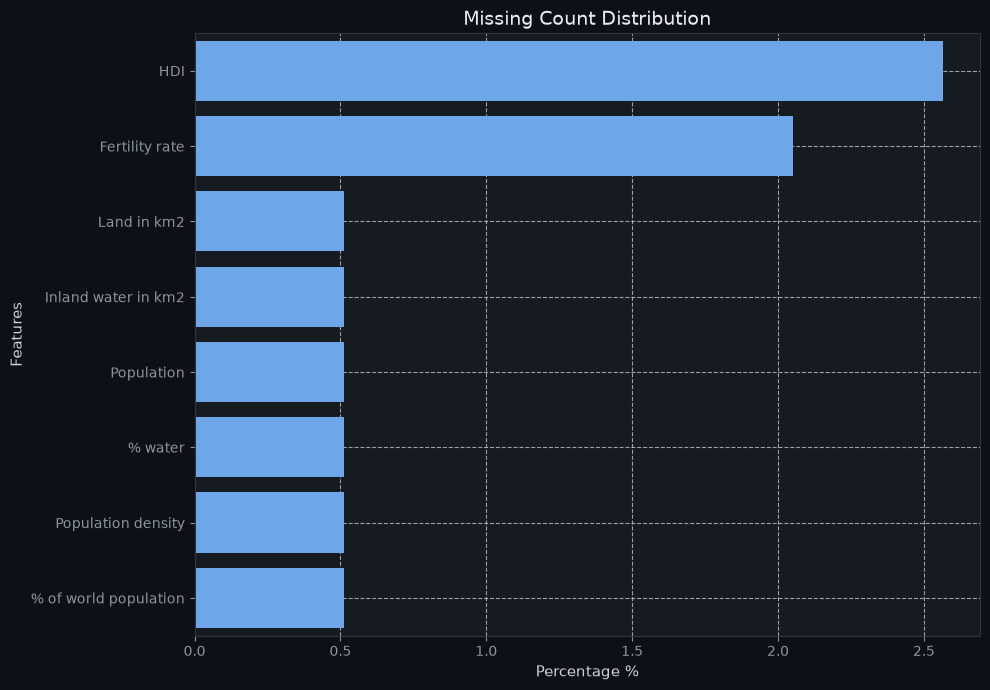

"Missing values observation:\n---------------------------------\n- Missing values are in 'HDI', 'Fertility rate', 'Land in km2', 'Population',\n'Inland water in km2', '% water', 'Population density' and '% of world population'\n(8 features summary).\n- Missing data is minimal across all dataframe (under 3%).\n- The most missing values are in 'HDI' (2.5% of summary df shape).\n"

In [9]:
df_missing = df.isna().sum()

missing_data = pd.DataFrame({
    "missing_count": df_missing,
    "missing_percent": (df_missing / len(df)) * 100
}).reset_index().rename(columns={'index': 'feature'})

missing_data = missing_data[missing_data['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=missing_data,
    x="missing_percent",
    y="feature"
)
plt.title("Missing Count Distribution")
plt.xlabel("Percentage %")
plt.ylabel("Features")
plt.tight_layout()
plt.grid(True)
plt.show()
"""Missing values observation:
---------------------------------
- Missing values are in 'HDI', 'Fertility rate', 'Land in km2', 'Population',
'Inland water in km2', '% water', 'Population density' and '% of world population'
(8 features summary).
- Missing data is minimal across all dataframe (under 3%).
- The most missing values are in 'HDI' (2.5% of summary df shape).
"""

In [10]:
skewness = df.select_dtypes("number").skew()
display(skewness.sort_values(ascending=False))
"""Dataframe features skewness observation:
-----------------------------------
- 'Population density' has the largest skew (11.05) and 'Population' have as well (8.32).
- 'Fertility rate' has moderate positive skew (1.07).
- 'HDI' is only one normally distributed feature with slight left skew (-0.41).
"""

Population density      11.05
Population               8.32
% of world population    8.31
Inland water in km2      7.56
Total in km2             5.59
Land in km2              5.53
% water                  3.22
Fertility rate           1.07
HDI                     -0.41
dtype: float64

"Dataframe features skewness observation:\n-----------------------------------\n- 'Population density' has the largest skew (11.05) and 'Population' have as well (8.32).\n- 'Fertility rate' has moderate positive skew (1.07).\n- 'HDI' is only one normally distributed feature with slight left skew (-0.41).\n"

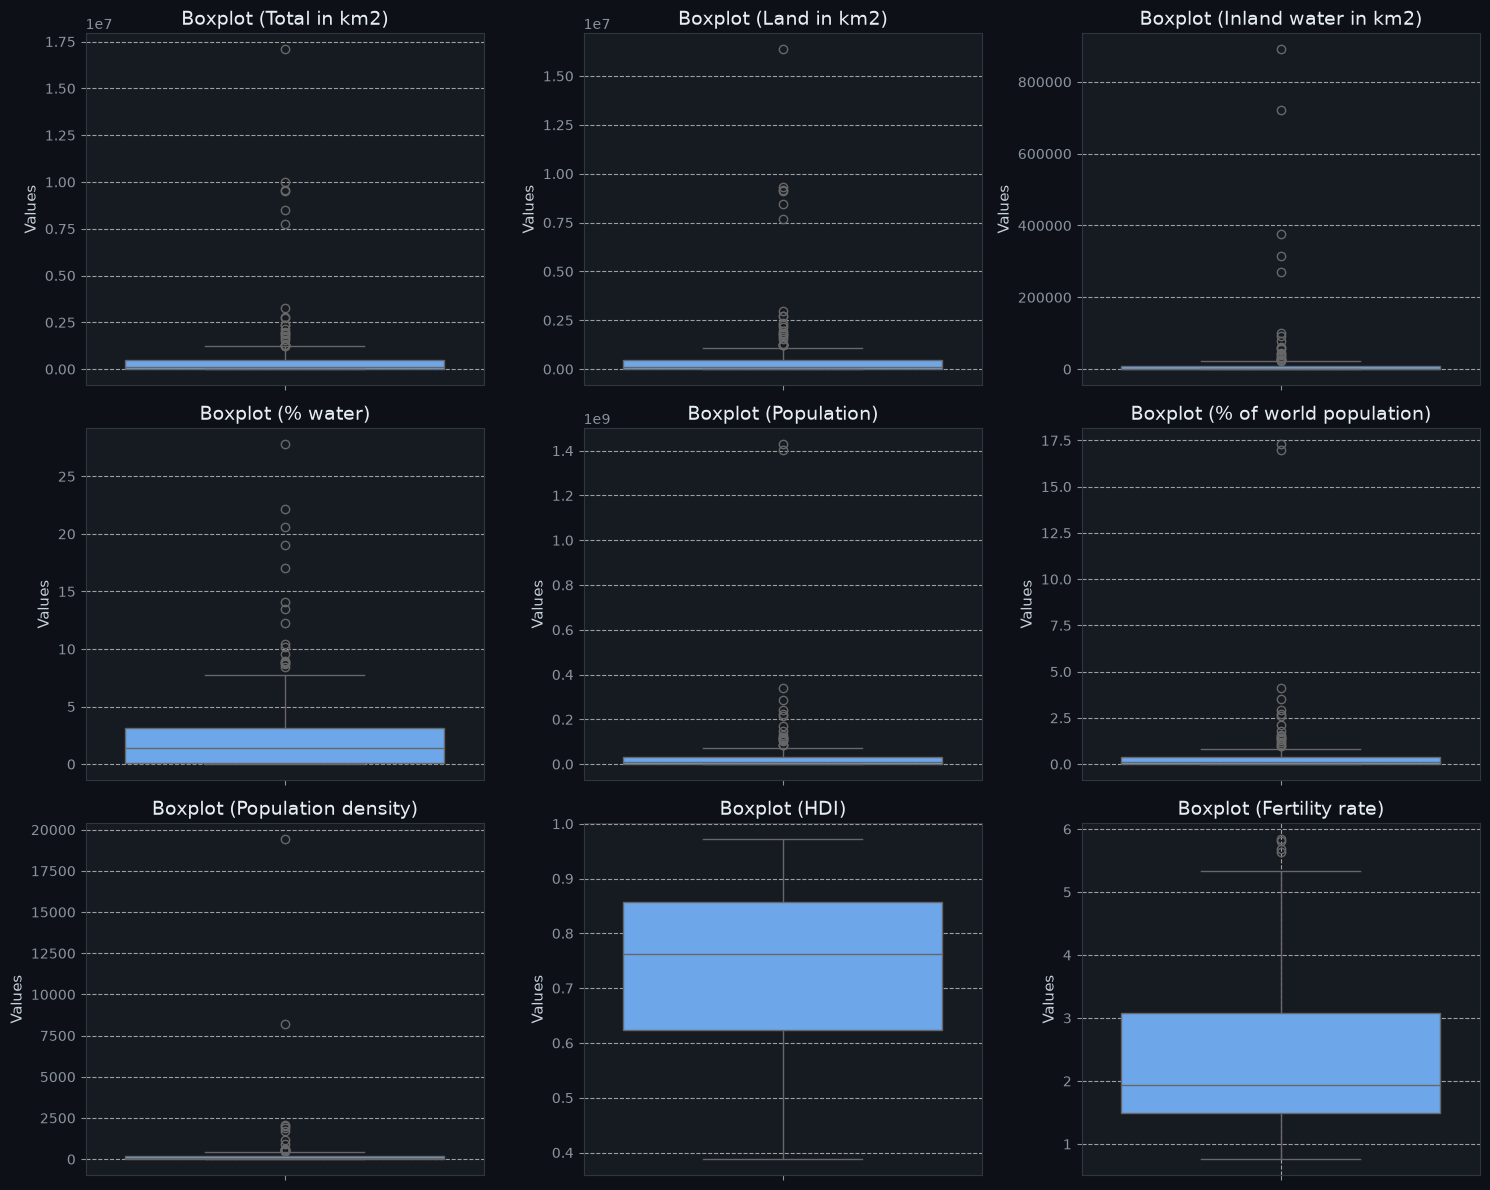

In [11]:
num_cols = df.select_dtypes("number").columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot ({col})")
    axes[i].set_ylabel("Values")

for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.grid(True)
plt.show()

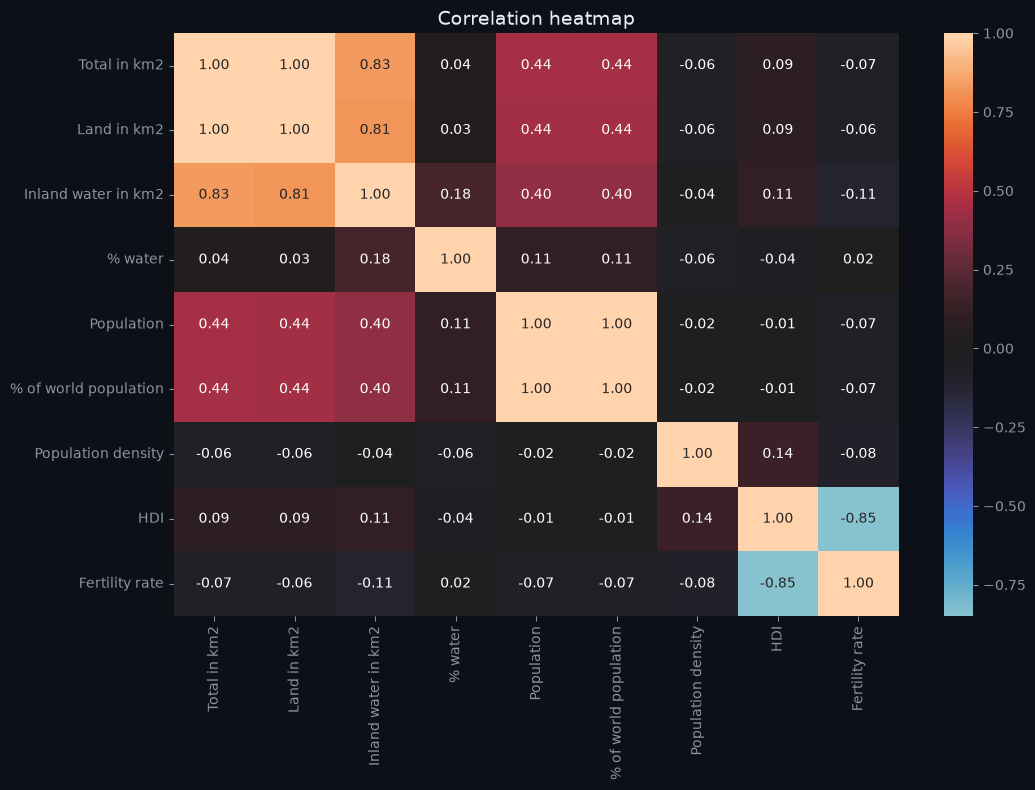

"Dataframe heatmap observation:\n-------------------------------------\n- 'Total in km2' and 'Land in km2' obviously duplicated features (corr = 1.00).\n'Population' and '% of world Population' also repeated and only distract model in future.\n- 'Island water in km2' and 'Total in km2' have strong synergy (corr = 0.81).\n- 'HDI' and 'Fertility rate' have strong invertible synergy (corr = -0.85).\nThey show different meanings - they higher the level of human development\nin a country, the lower the fertility rate.\n"

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()
"""Dataframe heatmap observation:
-------------------------------------
- 'Total in km2' and 'Land in km2' obviously duplicated features (corr = 1.00).
'Population' and '% of world Population' also repeated and only distract model in future.
- 'Island water in km2' and 'Total in km2' have strong synergy (corr = 0.81).
- 'HDI' and 'Fertility rate' have strong invertible synergy (corr = -0.85).
They show different meanings - they higher the level of human development
in a country, the lower the fertility rate.
"""

In [13]:
neg_val = (df.select_dtypes('number') < 0).sum()
neg_cols = neg_val[neg_val > 0]
print(f"Negative: {len(neg_cols)} columns") # Dataframe doesn't have negative values.

water_over_100 = (df["% water"] > 100).any()
print(f"Water > 100%: {water_over_100}") # Dataframe water percentage doesn't exceed 100.

calculated_density = df["Population"] / df["Land in km2"]
density_diff = (df["Population density"] - calculated_density).abs()
print(f"Max density diff: {density_diff.max():.3f}") # Have some differences (160.730)

Negative: 0 columns
Water > 100%: False
Max density diff: 160.730


In [15]:
check_df = df.copy()
check_df["calc_density_land"] = check_df["Population"] / check_df["Land in km2"]
check_df["calc_density_total"] = check_df["Population"] / check_df["Total in km2"]

check_df["diff"] = (check_df["Population density"] - check_df["calc_density_land"]).abs()
check_df = check_df.sort_values(by="diff", ascending=False)

display(check_df[
    ["Country name", "Population density", "calc_density_land", "calc_density_total", "diff"]
])
"""Dataframe validation:
-----------------------------
- 'Population density' matches 'calc_density_total' across dataframe.
That means, density was calculated by total land instead of specific country,
explaining maximum difference (160.730).
- No negative values were found across numeric features.
- Water percentage values are logical and within valid boundaries (<= 100%).
"""

,Country name,Population density,calc_density_land,calc_density_total,diff
91,Bangladesh,1143.94,1304.67,1143.94,160.73
175,Singapore,8201.61,8313.20,8201.61,111.59
130,Netherlands,433.61,535.61,433.61,102.00
97,Malawi,178.94,225.36,178.94,46.42
6,India,434.83,480.76,434.83,45.93
78,Uganda,190.05,228.93,190.05,38.88
141,Burundi,443.08,480.25,443.08,37.17
143,Rwanda,547.43,584.44,547.43,37.01
119,Sri Lanka,323.56,351.70,323.56,28.14
192,Nauru,556.19,584.00,556.19,27.81
